In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv',encoding='latin-1')

In [ ]:
df.shape

(1503, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   object 
 1   RANK_2024                             1482 non-null   object 
 2   Institution_Name                      1503 non-null   object 
 3   Location                              1503 non-null   object 
 4   Region                                1503 non-null   object 
 5   SIZE                                  1503 non-null   object 
 6   FOCUS                                 1503 non-null   object 
 7   RES.                                  1503 non-null   object 
 8   STATUS                                1466 non-null   object 
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   object 
 11  Employer_Reputati

In [ ]:
df['Overall_Score']=df['Overall_Score'].replace('-',np.nan).astype(float)

In [ ]:
obj_cols=[col for col in df.columns if df[col].dtype=='object']


In [ ]:
obj_cols

['RANK_2025',
 'RANK_2024',
 'Institution_Name',
 'Location',
 'Region',
 'SIZE',
 'FOCUS',
 'RES.',
 'STATUS',
 'Academic_Reputation_Rank',
 'Employer_Reputation_Rank',
 'Faculty_Student_Rank',
 'Citations_per_Faculty_Rank',
 'International_Faculty_Rank',
 'International_Students_Rank',
 'International_Research_Network_Rank',
 'Employment_Outcomes_Rank',
 'Sustainability_Rank']

In [ ]:
df['RANK_2025']=df['RANK_2025'].str.split('-').str[0].str.replace('+','')

In [ ]:
# size , res ordinal encoding
df=df[df['RANK_2025'].str.isnumeric()]

In [ ]:
df['RANK_2025']=df['RANK_2025'].astype(int)

In [ ]:
nan_columns=[col for col in df.columns if df[col].isna().sum()>0]

In [ ]:
nan_columns

['RANK_2024',
 'STATUS',
 'International_Faculty_Score',
 'International_Faculty_Rank',
 'International_Students_Score',
 'International_Students_Rank',
 'International_Research_Network_Score',
 'International_Research_Network_Rank',
 'Sustainability_Score',
 'Sustainability_Rank',
 'Overall_Score']

In [ ]:
nan_obj_columns=[col for col in nan_columns if col in obj_cols]

In [ ]:
nan_obj_columns

['RANK_2024',
 'STATUS',
 'International_Faculty_Rank',
 'International_Students_Rank',
 'International_Research_Network_Rank',
 'Sustainability_Rank']

In [ ]:
df[nan_obj_columns] # Status --> ordinal encoding

,RANK_2024,STATUS,International_Faculty_Rank,International_Students_Rank,International_Research_Network_Rank,Sustainability_Rank
0,1,B,100,143,58,15=
1,6,A,66,44,34,6
2,3,A,120,73,1,126
3,4,B,269,215,5,130
4,2,A,73,98,10,127=
...,...,...,...,...,...,...
1498,1201-1400,A,701+,701+,701+,701+
1499,1401+,A,701+,701+,701+,701+
1500,1201-1400,C,701+,701+,701+,701+
1501,1401+,A,701+,701+,701+,701+


In [ ]:
df['International_Faculty_Rank']

,International_Faculty_Rank
0,100
1,66
2,120
3,269
4,73
...,...
1498,701+
1499,701+
1500,701+
1501,701+


In [ ]:
df.shape

(1503, 28)

In [ ]:
nan_obj_columns

['RANK_2024',
 'STATUS',
 'International_Faculty_Rank',
 'International_Students_Rank',
 'International_Research_Network_Rank',
 'Sustainability_Rank']

In [ ]:
df['International_Faculty_Rank']=df['International_Faculty_Rank'].replace('-',np.nan).str.replace('+','').str.replace('=','').astype(float)

In [ ]:
df['International_Students_Rank']=df['International_Students_Rank'].replace('-',np.nan).str.replace('+','').str.replace('=','').astype(float)
df['International_Research_Network_Rank']=df['International_Research_Network_Rank'].replace('-',np.nan).str.replace('+','').str.replace('=','').astype(float)
df['Sustainability_Rank']=df['Sustainability_Rank'].replace('-',np.nan).str.replace('+','').str.replace('=','').astype(float)

In [ ]:
df['RANK_2024']=df['RANK_2024'].str.split('-')

In [ ]:
df['RANK_2024']=df['RANK_2024'].str[0].str.replace('+','')

In [ ]:
df['RANK_2024']=df['RANK_2024'].replace('-',np.nan).astype(float)

In [ ]:
nan_not_obj_column=[col  for col in nan_columns if col not in nan_obj_columns]

In [ ]:
nan_not_obj_column

['International_Faculty_Score',
 'International_Students_Score',
 'International_Research_Network_Score',
 'Sustainability_Score',
 'Overall_Score']

In [ ]:
df[nan_not_obj_column].sample(10)

,International_Faculty_Score,International_Students_Score,International_Research_Network_Score,Sustainability_Score,Overall_Score
1184,92.4,2.2,38.0,1.0,NaN
66,15.2,45.7,65.7,85.2,69.0
489,14.2,37.8,29.9,49.5,24.5
325,6.6,3.3,12.3,3.1,34.0
825,5.8,39.3,55.5,11.6,NaN
1339,1.6,3.7,24.5,1.1,NaN
409,6.6,13.5,83.6,44.6,29.0
320,68.7,8.2,22.8,10.5,34.2
754,3.5,28.6,64.2,16.1,NaN
937,8.3,6.2,81.4,29.6,NaN


In [ ]:
df1=df[~df['Overall_Score'].isna()]

In [ ]:
new_dataset=df[df['Overall_Score'].isna()]

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 632
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             600 non-null    int64  
 1   RANK_2024                             596 non-null    float64
 2   Institution_Name                      600 non-null    object 
 3   Location                              600 non-null    object 
 4   Region                                600 non-null    object 
 5   SIZE                                  600 non-null    object 
 6   FOCUS                                 600 non-null    object 
 7   RES.                                  600 non-null    object 
 8   STATUS                                595 non-null    object 
 9   Academic_Reputation_Score             600 non-null    float64
 10  Academic_Reputation_Rank              600 non-null    object 
 11  Employer_Reputation_Scor

In [ ]:
df1['Employment_Outcomes_Rank']=df1['Employment_Outcomes_Rank'].str.replace('+','')

<ipython-input-194-33918899>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Employment_Outcomes_Rank']=df1['Employment_Outcomes_Rank'].str.replace('+','')


In [ ]:
df1['Employment_Outcomes_Rank']=df1['Employment_Outcomes_Rank'].astype(int)

<ipython-input-149-3325660157>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Employment_Outcomes_Rank']=df1['Employment_Outcomes_Rank'].astype(int)


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 632
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             600 non-null    int64  
 1   RANK_2024                             596 non-null    float64
 2   Institution_Name                      600 non-null    object 
 3   Location                              600 non-null    object 
 4   Region                                600 non-null    object 
 5   SIZE                                  600 non-null    object 
 6   FOCUS                                 600 non-null    object 
 7   RES.                                  600 non-null    object 
 8   STATUS                                595 non-null    object 
 9   Academic_Reputation_Score             600 non-null    float64
 10  Academic_Reputation_Rank              600 non-null    object 
 11  Employer_Reputation_Scor

In [ ]:
df1['Academic_Reputation_Rank']=df1['Academic_Reputation_Rank'].str.replace('+','')

<ipython-input-196-1529494860>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Academic_Reputation_Rank']=df1['Academic_Reputation_Rank'].str.replace('+','')


In [ ]:
df1['Academic_Reputation_Rank']=df1['Academic_Reputation_Rank'].astype(int)

<ipython-input-197-1255868878>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Academic_Reputation_Rank']=df1['Academic_Reputation_Rank'].astype(int)


In [ ]:
df1['Employer_Reputation_Rank']=df1['Employer_Reputation_Rank'].str.replace('+','').astype(int)

<ipython-input-198-1888970148>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Employer_Reputation_Rank']=df1['Employer_Reputation_Rank'].str.replace('+','').astype(int)


In [ ]:
df1['Faculty_Student_Rank']=df1['Faculty_Student_Rank'].str.replace('+','').astype(int)

<ipython-input-199-3418029742>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Faculty_Student_Rank']=df1['Faculty_Student_Rank'].str.replace('+','').astype(int)


In [ ]:
df1['Citations_per_Faculty_Rank']=df1['Citations_per_Faculty_Rank'].str.replace('+','').astype(int)

<ipython-input-200-4129073424>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Citations_per_Faculty_Rank']=df1['Citations_per_Faculty_Rank'].str.replace('+','').astype(int)


In [ ]:
df1.iloc[:,2:9]

,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS
0,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B
1,Imperial College London,United Kingdom,Europe,L,FC,VH,A
2,University of Oxford,United Kingdom,Europe,L,FC,VH,A
3,Harvard University,United States,Americas,L,FC,VH,B
4,University of Cambridge,United Kingdom,Europe,L,FC,VH,A
...,...,...,...,...,...,...,...
596,Universitas Padjadjaran,Indonesia,Asia,XL,FO,VH,A
597,University of Iowa,United States,Americas,L,FC,VH,A
598,University of Ljubljana,Slovenia,Europe,XL,FC,VH,A
599,University of Texas Dallas,United States,Americas,L,FC,VH,A


In [ ]:
x=df1.drop(columns='Overall_Score',axis=1)
y=df1['Overall_Score']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.sample(5)

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank
388,389,595.0,Università Vita-Salute San Raffaele,Italy,Europe,S,SP,VH,B,3.3,...,4.4,701.0,4.3,701.0,39.2,701.0,2.1,701,1.2,701.0
149,150,197.0,Indian Institute of Technology Delhi (IITD),India,Asia,M,FO,VH,A,54.1,...,3.1,701.0,1.5,701.0,63.3,582.0,35.1,361,32.7,424.0
231,232,220.0,Universidade Estadual de Campinas (Unicamp),Brazil,Americas,XL,FC,VH,A,71.8,...,10.7,701.0,2.7,701.0,85.4,241.0,25.1,465,65.9,236.0
18,19,19.0,The University of New South Wales (UNSW Sydney),Australia,Oceania,XL,FC,VH,A,90.5,...,100.0,57.0,99.4,48.0,98.3,20.0,97.7,29,99.2,11.0
252,252,295.0,Hong Kong Baptist University,Hong Kong SAR,Asia,M,CO,VH,A,18.2,...,98.9,109.0,100.0,19.0,37.0,701.0,15.7,641,54.4,291.0


In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 145 to 102
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             480 non-null    int64  
 1   RANK_2024                             478 non-null    float64
 2   Institution_Name                      480 non-null    object 
 3   Location                              480 non-null    object 
 4   Region                                480 non-null    object 
 5   SIZE                                  480 non-null    object 
 6   FOCUS                                 480 non-null    object 
 7   RES.                                  480 non-null    object 
 8   STATUS                                479 non-null    object 
 9   Academic_Reputation_Score             480 non-null    float64
 10  Academic_Reputation_Rank              480 non-null    int64  
 11  Employer_Reputation_Sc

In [ ]:
x_train.describe()

,RANK_2025,RANK_2024,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank
count,480.000000,478.000000,480.000000,480.00000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,474.000000,474.000000,479.000000,479.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000
mean,299.841667,303.742678,37.184167,325.35000,36.393958,348.235417,38.358542,462.150000,46.221875,353.406250,51.099789,397.721519,42.370355,413.098121,72.191875,377.493750,38.187083,419.725000,49.036667,354.812500
std,170.516188,184.219433,26.636385,194.76052,28.462610,207.031612,31.116341,247.707498,31.242425,234.541528,36.605685,238.930940,35.112938,244.309703,22.515258,236.859877,30.421152,240.525181,33.060634,228.042432
min,1.000000,1.000000,3.100000,1.00000,1.800000,1.000000,1.900000,3.000000,1.100000,1.000000,1.100000,1.000000,1.100000,1.000000,5.700000,2.000000,1.300000,1.000000,1.000000,3.000000
25%,153.500000,151.500000,17.975000,158.75000,12.950000,156.750000,11.050000,221.750000,19.575000,141.750000,14.200000,182.000000,10.700000,178.000000,60.575000,169.750000,13.000000,205.500000,16.300000,154.750000
50%,303.000000,300.500000,27.900000,316.00000,27.700000,347.500000,28.900000,535.500000,42.400000,325.000000,47.300000,377.500000,31.000000,420.000000,78.250000,354.500000,29.700000,419.500000,50.300000,317.000000
75%,448.750000,445.500000,50.875000,504.25000,54.050000,601.000000,62.550000,701.000000,73.375000,560.500000,91.400000,679.750000,78.500000,701.000000,89.750000,627.250000,59.700000,701.000000,80.075000,570.000000
max,596.000000,1401.000000,100.000000,601.00000,100.000000,601.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,99.900000,701.000000,100.000000,701.000000,99.800000,701.000000


In [ ]:
from sklearn.impute import SimpleImputer
si=SimpleImputer()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.impute import KNNImputer
knn=KNNImputer(n_neighbors=10)

In [ ]:
x_train['STATUS'].unique()

array(['A', 'B', 'C', nan], dtype=object)

In [ ]:
nan_columns

In [ ]:
dic={'A':2.0,'B':1.0,'C':0.0,'':np.nan}

In [ ]:
x_train['STATUS']=x_train['STATUS'].map(dic)
x_test['STATUS']=x_test['STATUS'].map(dic)

In [ ]:
x_train['STATUS']=knn.fit_transform(pd.DataFrame(x_train['STATUS']))
x_test['STATUS']=knn.transform(pd.DataFrame(x_test['STATUS']))
x_train['International_Faculty_Score']=knn.fit_transform(pd.DataFrame(x_train['International_Faculty_Score']))
x_test['International_Faculty_Score']=knn.transform(pd.DataFrame(x_test['International_Faculty_Score']))
x_train['International_Faculty_Rank']=knn.fit_transform(pd.DataFrame(x_train['International_Faculty_Rank']))
x_test['International_Faculty_Rank']=knn.transform(pd.DataFrame(x_test['International_Faculty_Rank']))
x_train['International_Students_Score']=knn.fit_transform(pd.DataFrame(x_train['International_Students_Score']))
x_test['International_Students_Score']=knn.transform(pd.DataFrame(x_test['International_Students_Score']))
x_train['International_Students_Rank']=knn.fit_transform(pd.DataFrame(x_train['International_Students_Rank']))
x_test['International_Students_Rank']=knn.transform(pd.DataFrame(x_test['International_Students_Rank']))
x_train['International_Research_Network_Score']=knn.fit_transform(pd.DataFrame(x_train['International_Research_Network_Score']))
x_test['International_Research_Network_Score']=knn.fit_transform(pd.DataFrame(x_test['International_Research_Network_Score']))
x_train['International_Research_Network_Rank']=knn.fit_transform(pd.DataFrame(x_train['International_Research_Network_Rank']))
x_test['International_Research_Network_Rank']=knn.fit_transform(pd.DataFrame(x_test['International_Research_Network_Rank']))
x_train['Sustainability_Score']=knn.fit_transform(pd.DataFrame(x_train['Sustainability_Score']))
x_test['Sustainability_Score']=knn.fit_transform(pd.DataFrame(x_test['Sustainability_Score']))
x_train['Sustainability_Rank']=knn.fit_transform(pd.DataFrame(x_train['Sustainability_Rank']))
x_test['Sustainability_Rank']=knn.fit_transform(pd.DataFrame(x_test['Sustainability_Rank']))

In [ ]:
x_train['RANK_2024']=si.fit_transform(pd.DataFrame(x_train['RANK_2024']))
x_test['RANK_2024']=si.transform(pd.DataFrame(x_test['RANK_2024']))

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 145 to 102
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             480 non-null    int64  
 1   RANK_2024                             480 non-null    float64
 2   Institution_Name                      480 non-null    object 
 3   Location                              480 non-null    object 
 4   Region                                480 non-null    object 
 5   SIZE                                  480 non-null    object 
 6   FOCUS                                 480 non-null    object 
 7   RES.                                  480 non-null    object 
 8   STATUS                                480 non-null    float64
 9   Academic_Reputation_Score             480 non-null    float64
 10  Academic_Reputation_Rank              480 non-null    int64  
 11  Employer_Reputation_Sc

In [ ]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 110 to 439
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             120 non-null    int64  
 1   RANK_2024                             120 non-null    float64
 2   Institution_Name                      120 non-null    object 
 3   Location                              120 non-null    object 
 4   Region                                120 non-null    object 
 5   SIZE                                  120 non-null    object 
 6   FOCUS                                 120 non-null    object 
 7   RES.                                  120 non-null    object 
 8   STATUS                                120 non-null    float64
 9   Academic_Reputation_Score             120 non-null    float64
 10  Academic_Reputation_Rank              120 non-null    int64  
 11  Employer_Reputation_Sc

In [ ]:
x_train=x_train.reset_index()
x_test=x_test.reset_index()
y_train=y_train.reset_index()
y_test=y_test.reset_index()
y_train=y_train.drop('index',axis=1)
y_test=y_test.drop('index',axis=1)
x_train=x_train.drop('index',axis=1)
x_test=x_test.drop('index',axis=1)

In [ ]:
x_train['Location'].nunique()

62

In [ ]:
x_train['Region'].nunique()

5

<Axes: xlabel='Region'>

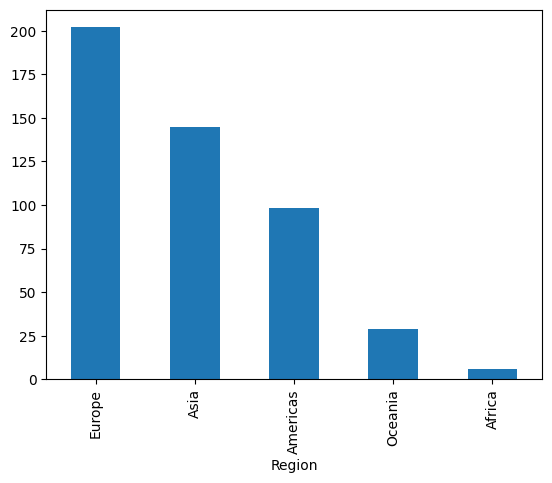

In [ ]:
x_train['Region'].value_counts().plot(kind='bar')

<Axes: xlabel='Location'>

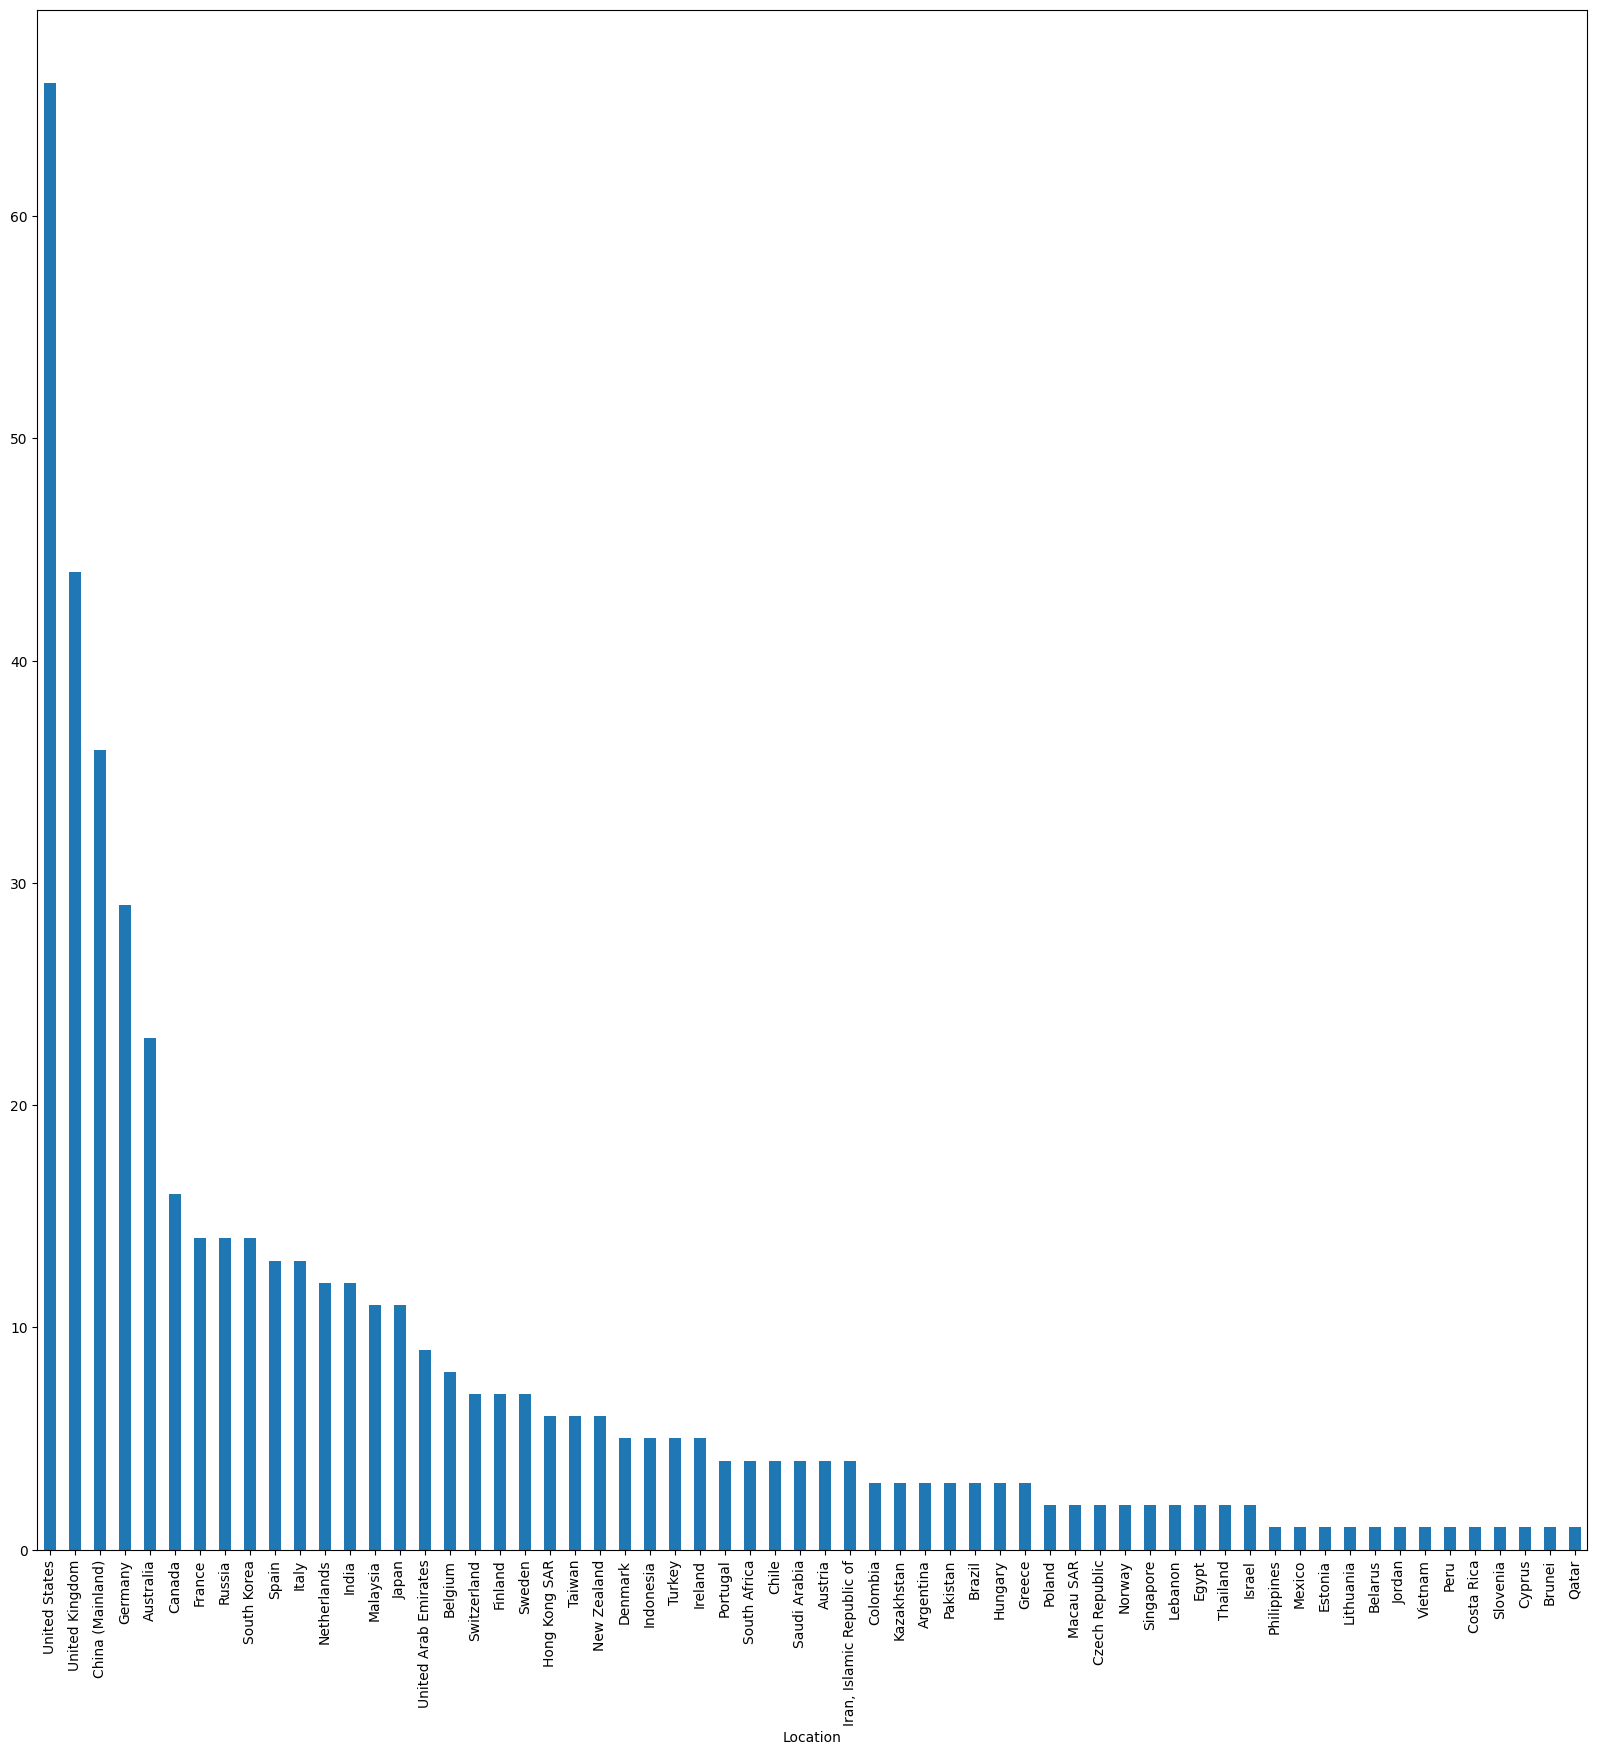

In [ ]:
x_train['Location'].value_counts().plot(kind='bar',figsize=(20,20))

In [ ]:
import seaborn as sns
plt.figure(figsize=(20,20))
sns.barplot(x='Location',y='Overall_Score',data=df1)
plt.show()

In [ ]:
location_preference=df1.groupby(df1['Location'])['Overall_Score'].sum().sort_values(ascending=False)

<ipython-input-221-818815323>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pd.DataFrame(location_preference)['Overall_Score'])


<Axes: xlabel='Overall_Score', ylabel='Density'>

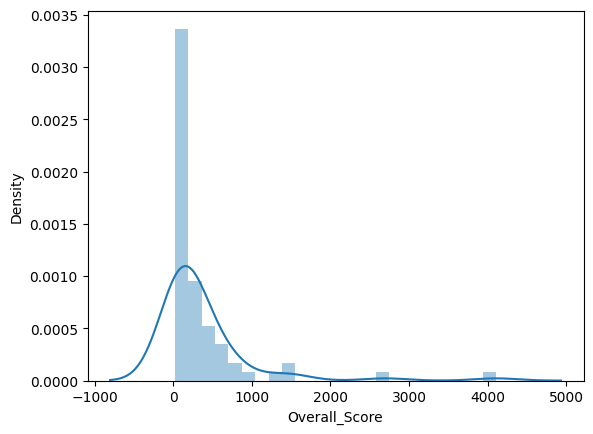

In [ ]:
sns.distplot(pd.DataFrame(location_preference)['Overall_Score'])

In [ ]:
location=pd.DataFrame(location_preference)

<Axes: ylabel='Overall_Score'>

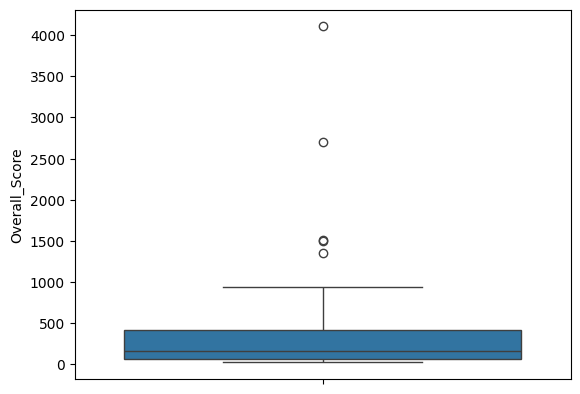

In [ ]:
sns.boxplot(location['Overall_Score'])

In [ ]:
location[location['Overall_Score']>500]

,Overall_Score
Location,
United States,4108.2
United Kingdom,2698.4
Australia,1506.4
China (Mainland),1494.7
Germany,1347.7
Canada,939.0
South Korea,750.9
France,705.8
Japan,696.9


In [ ]:
location_categories=['United States','United Kingdom','Australia','China (Mainland)','Germany','Canada','South Korea','France','Japan','Netherlands','Italy','Spain','Malaysia','India']

In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',handle_unknown='ignore')

In [ ]:
for index,item in enumerate(x_train['Location']):
  if item not in location_categories:
    x_train['Location'][index]='Others'


<ipython-input-265-1305180879>:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Location'][index]='Others'
<ipython-input-265-1305180879>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame


In [ ]:
for index,item in enumerate(x_test['Location']):
  if item not in location_categories:
    x_test['Location'][index]='Others'

In [ ]:
ohe.fit_transform(x_train[['Location']]).toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
enc_location_train=pd.get_dummies(x_train,columns=['Location'],drop_first=True).iloc[:,26:41].astype(int)

In [ ]:
enc_location_test=pd.get_dummies(x_test,columns=['Location'],drop_first=True).iloc[:,26:41].astype(int)

In [ ]:
x_train.drop(columns=['Location','Region'],axis=1)
x_test.drop(columns=['Location','Region'],axis=1)

,RANK_2025,RANK_2024,Institution_Name,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,...,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank
0,111,123.0,Politecnico di Milano,XL,FO,VH,2.000000,70.8,90,77.0,...,67.400000,292.000000,56.800000,262.000000,88.1,197.0,52.9,239,72.6,202.0
1,420,454.0,Czech Technical University in Prague,L,SP,VH,2.000000,22.0,404,42.4,...,19.900000,598.000000,50.200000,293.000000,59.4,639.0,15.6,642,5.8,701.0
2,567,571.0,Chiang Mai University,XL,FC,HI,2.000000,34.8,252,17.1,...,4.800000,701.000000,4.200000,701.000000,62.5,596.0,19.1,578,56.1,282.0
3,78,76.0,University of Glasgow,XL,FC,VH,2.000000,77.4,75,67.7,...,95.700000,141.000000,99.400000,49.000000,97.6,30.0,33.5,378,98.5,20.0
4,181,199.0,Waseda University,XL,CO,VH,1.000000,60.7,122,96.1,...,27.900000,507.000000,28.000000,445.000000,66.4,533.0,83.7,106,56.1,282.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,396,410.0,University of Southern Queensland,M,CO,VH,2.000000,8.8,601,5.7,...,84.100000,223.000000,23.000000,503.000000,81.0,310.0,8.6,701,43.0,353.0
116,340,326.0,University of South Australia,L,CO,VH,2.000000,21.3,411,12.7,...,99.800000,92.000000,50.900000,290.000000,85.5,238.0,15.5,644,83.6,132.0
117,149,143.0,King Abdulaziz University (KAU),XL,FC,VH,2.000000,59.8,125,61.4,...,89.300000,195.000000,9.500000,701.000000,93.1,118.0,35.9,353,58.4,275.0
118,495,590.0,Central Queensland University (CQUniversity Au...,S,FO,VH,2.000000,9.0,601,6.7,...,97.100000,128.000000,97.800000,72.000000,44.0,701.0,3.1,701,49.8,319.0


In [ ]:
x_train=pd.concat([x_train.drop(columns=['Location','Region'],axis=1),enc_location_train],axis=1)


In [ ]:
x_test=pd.concat([x_test,enc_location_test],axis=1)

In [ ]:
x_train=x_train.drop(columns='Institution_Name',axis=1)
x_test=x_test.drop(columns='Institution_Name',axis=1)

In [ ]:
x_train['FOCUS'].unique()

array(['FC', 'CO', 'FO', 'SP'], dtype=object)

In [ ]:
res_enc={'VH':2,'HI':1,'MD':0}
focus_enc={'FC':3,'FO':2,'CO':1,'SP':0}
size_enc={'XL':3,'L':2,'M':1,'S':0}

In [ ]:
df1.groupby(df1['SIZE'])['Overall_Score'].mean()

,Overall_Score
SIZE,
L,42.378832
M,36.346535
S,31.902632
XL,46.037968


In [ ]:
df['RES.']=df['RES.'].map(res_enc)
df['FOCUS']=df['FOCUS'].map(focus_enc)
df['SIZE']=df['SIZE'].map(size_enc)
x_test['RES.']=x_test['RES.'].map(res_enc)
x_test['FOCUS']=x_test['FOCUS'].map(focus_enc)
x_test['SIZE']=x_test['SIZE'].map(size_enc)

In [ ]:
x_test

,RANK_2025,RANK_2024,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,Academic_Reputation_Rank,...,Location_India,Location_Italy,Location_Japan,Location_Malaysia,Location_Netherlands,Location_Others,Location_South Korea,Location_Spain,Location_United Kingdom,Location_United States
0,111,123.0,Italy,Europe,3,2,2,2.000000,70.8,90,...,0,1,0,0,0,0,0,0,0,0
1,420,454.0,Others,Europe,2,0,2,2.000000,22.0,404,...,0,0,0,0,0,1,0,0,0,0
2,567,571.0,Others,Asia,3,3,1,2.000000,34.8,252,...,0,0,0,0,0,1,0,0,0,0
3,78,76.0,United Kingdom,Europe,3,3,2,2.000000,77.4,75,...,0,0,0,0,0,0,0,0,1,0
4,181,199.0,Japan,Asia,3,1,2,1.000000,60.7,122,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,396,410.0,Australia,Oceania,1,1,2,2.000000,8.8,601,...,0,0,0,0,0,0,0,0,0,0
116,340,326.0,Australia,Oceania,2,1,2,2.000000,21.3,411,...,0,0,0,0,0,0,0,0,0,0
117,149,143.0,Others,Asia,3,3,2,2.000000,59.8,125,...,0,0,0,0,0,1,0,0,0,0
118,495,590.0,Australia,Oceania,0,2,2,2.000000,9.0,601,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x_train.columns

In [ ]:
import scipy.stats as stats

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

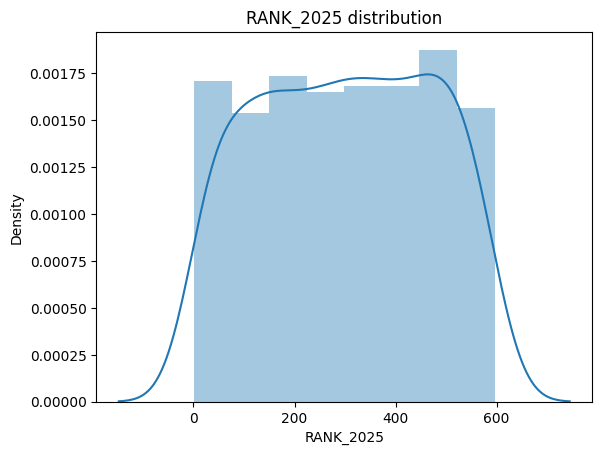

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


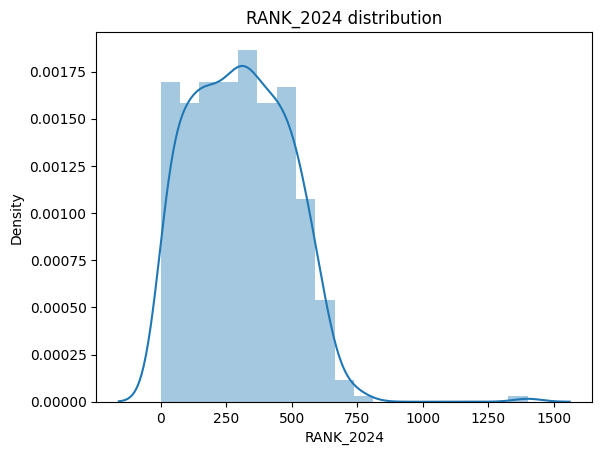

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


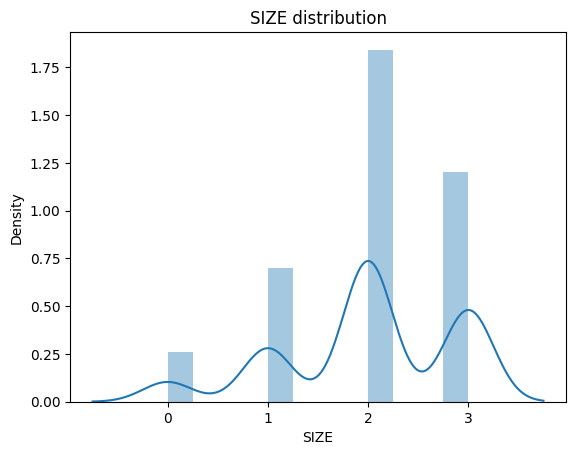

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


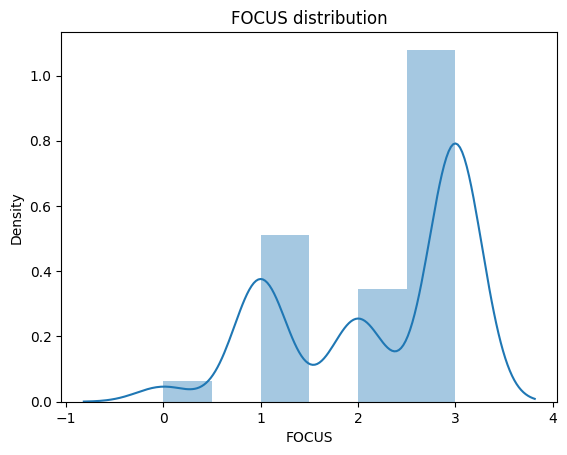

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


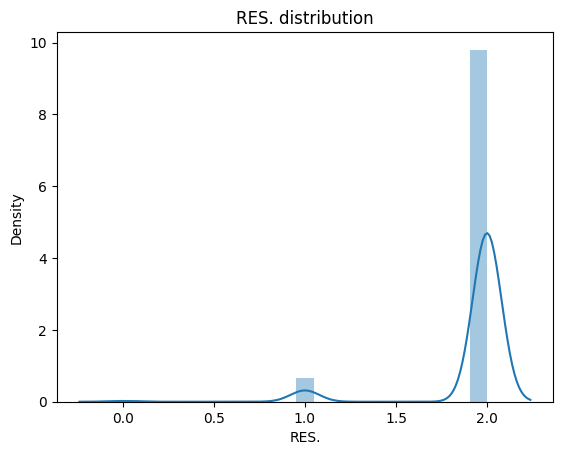

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


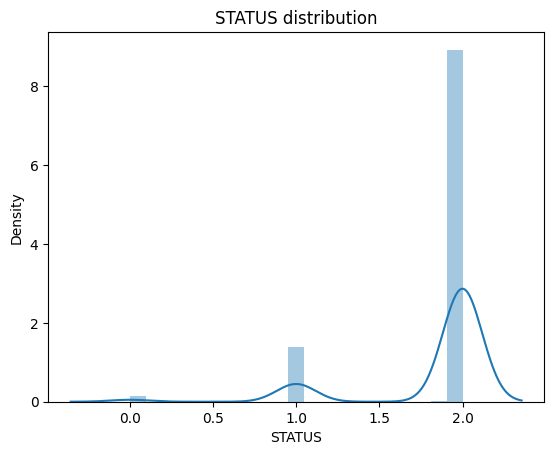

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


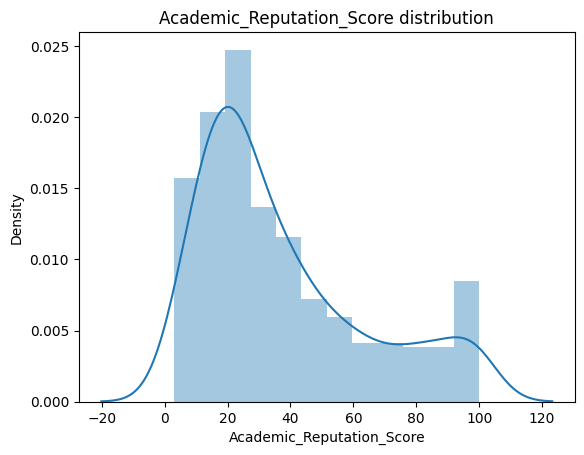

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


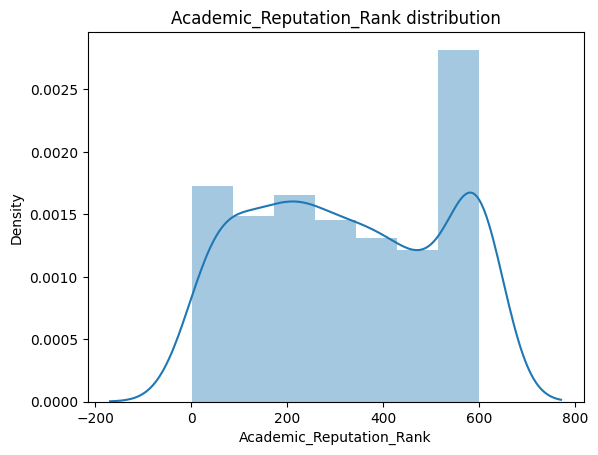

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


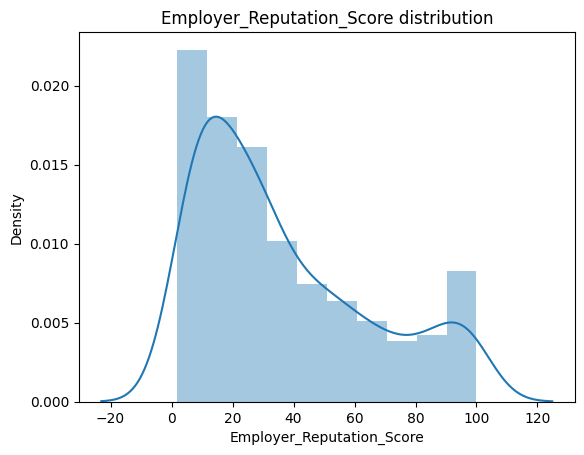

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


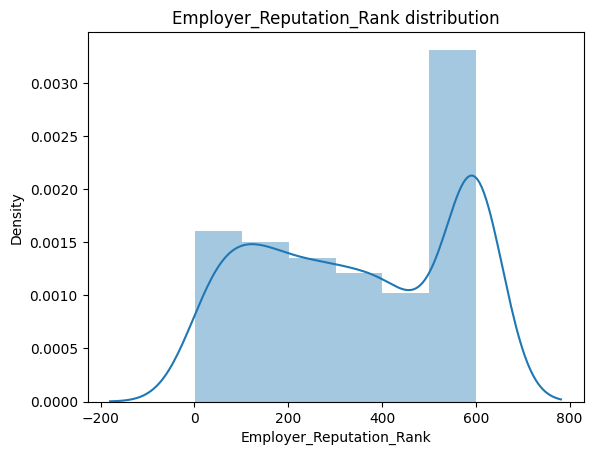

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


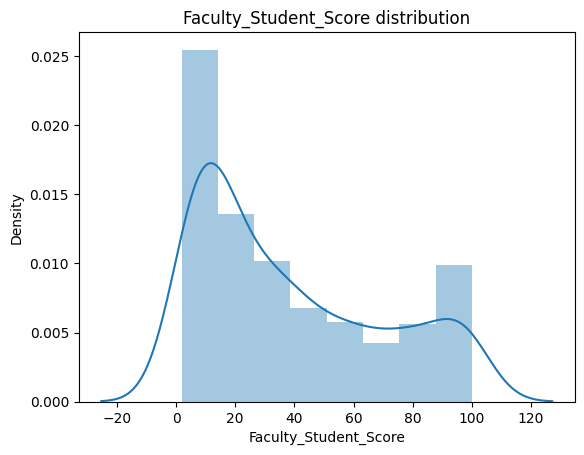

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


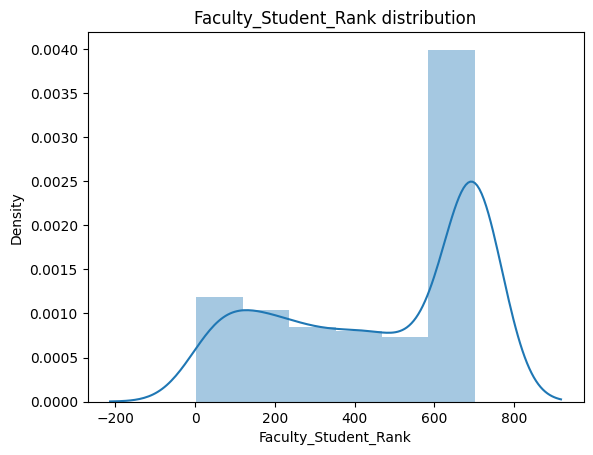

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


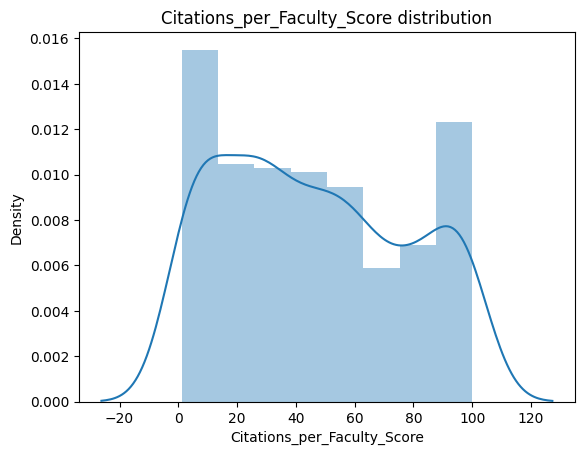

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


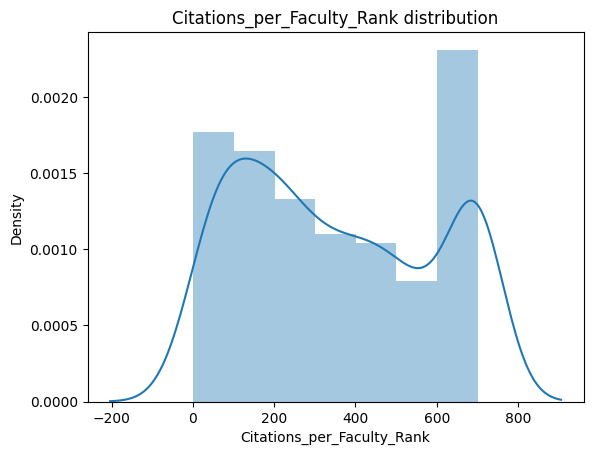

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


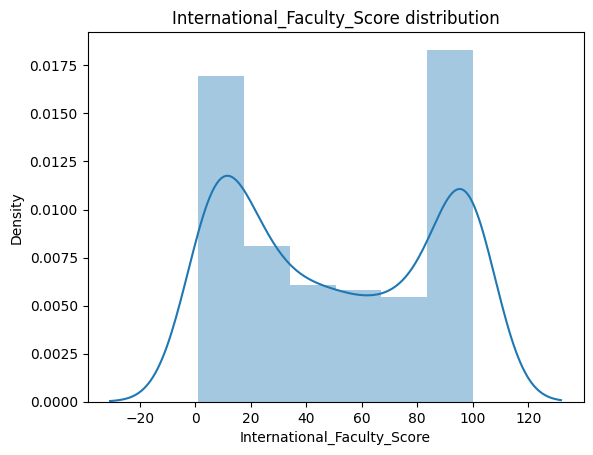

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


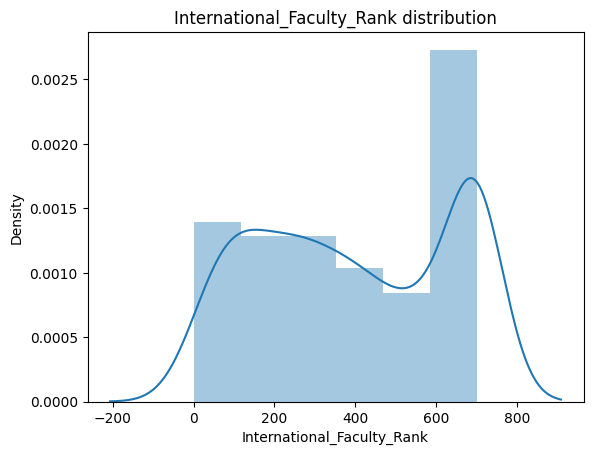

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


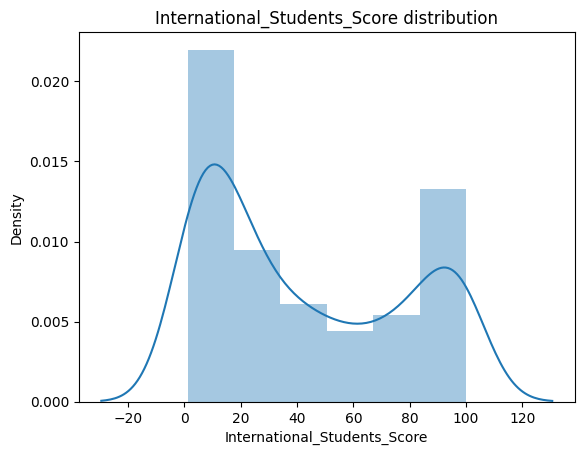

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


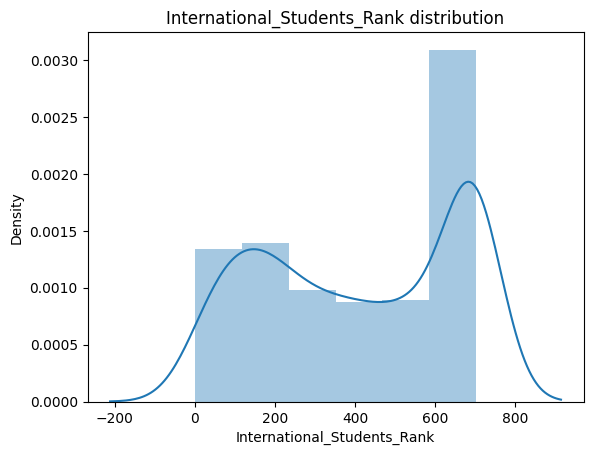

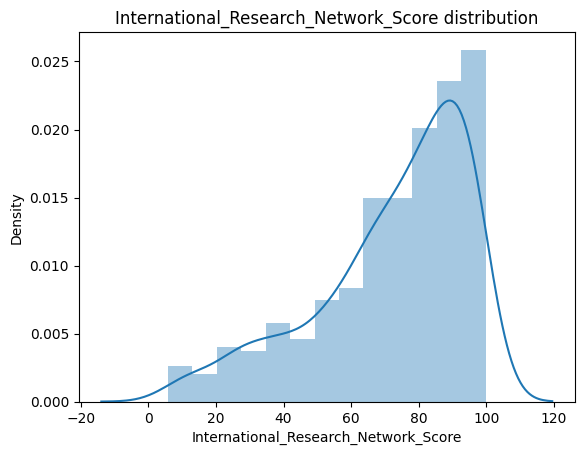

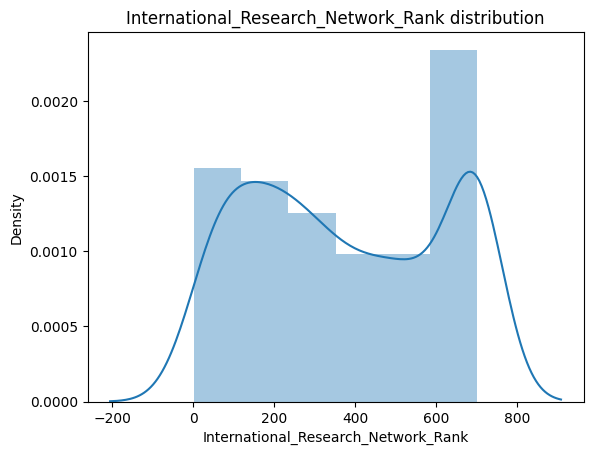

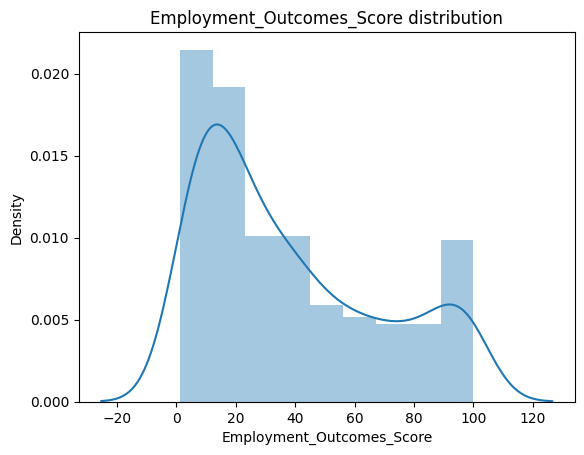

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


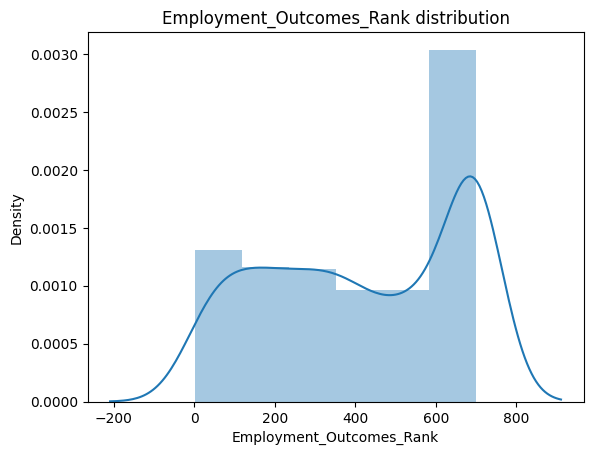

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


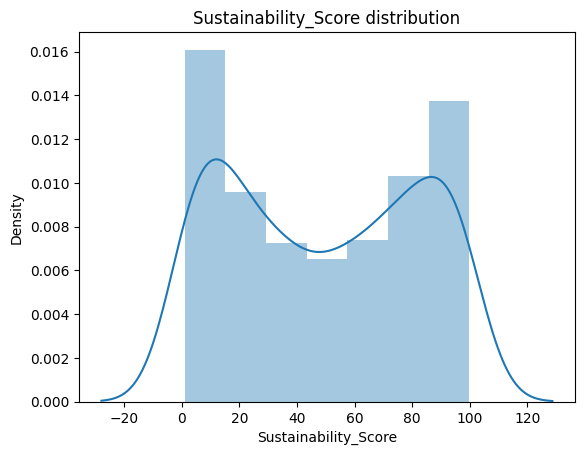

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


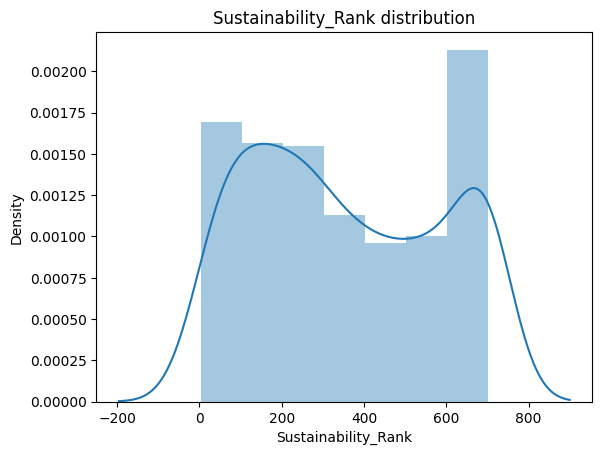

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


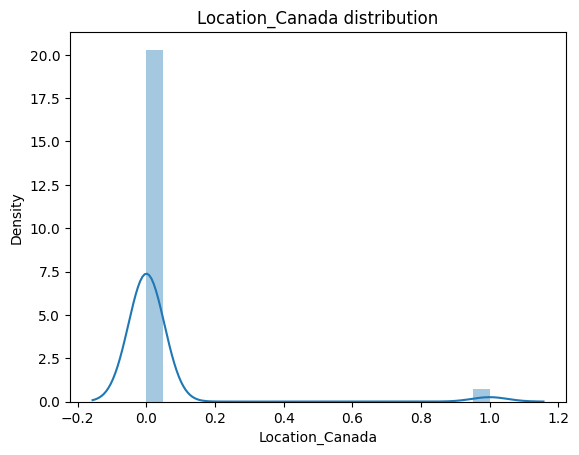

<ipython-input-280-4287569676>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


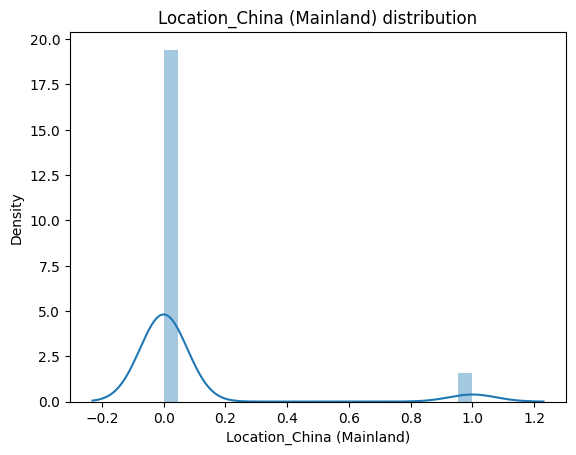

In [ ]:
# outlier
for index,col in enumerate(x_train.columns):
  if index>=26:
    break
  plt.title(f"{col} distribution")
  sns.distplot(x_train[col])
  plt.show()

In [ ]:
x_train.skew().index

Index(['RANK_2025', 'RANK_2024', 'SIZE', 'FOCUS', 'RES.', 'STATUS',
       'Academic_Reputation_Score', 'Academic_Reputation_Rank',
       'Employer_Reputation_Score', 'Employer_Reputation_Rank',
       'Faculty_Student_Score', 'Faculty_Student_Rank',
       'Citations_per_Faculty_Score', 'Citations_per_Faculty_Rank',
       'International_Faculty_Score', 'International_Faculty_Rank',
       'International_Students_Score', 'International_Students_Rank',
       'International_Research_Network_Score',
       'International_Research_Network_Rank', 'Employment_Outcomes_Score',
       'Employment_Outcomes_Rank', 'Sustainability_Score',
       'Sustainability_Rank', 'Location_Canada', 'Location_China (Mainland)',
       'Location_France', 'Location_Germany', 'Location_India',
       'Location_Italy', 'Location_Japan', 'Location_Malaysia',
       'Location_Netherlands', 'Location_Others', 'Location_South Korea',
       'Location_Spain', 'Location_United Kingdom', 'Location_United States'],
  

In [ ]:
x_train.skew().to_dict()

{'RANK_2025': -0.034913264871232426,
 'RANK_2024': 0.5341651107022317,
 'SIZE': -0.6110199157091005,
 'FOCUS': -0.6838646404373155,
 'RES.': -3.9607162095537984,
 'STATUS': -2.4647331095779994,
 'Academic_Reputation_Score': 0.9857230271713596,
 'Academic_Reputation_Rank': 0.03856947851250502,
 'Employer_Reputation_Score': 0.8424053247200121,
 'Employer_Reputation_Rank': -0.09102255270659745,
 'Faculty_Student_Score': 0.6727971602316427,
 'Faculty_Student_Rank': -0.4597112000708211,
 'Citations_per_Faculty_Score': 0.2394974860563902,
 'Citations_per_Faculty_Rank': 0.2122753630237881,
 'International_Faculty_Score': 0.08610835076723607,
 'International_Faculty_Rank': -0.023526405381147444,
 'International_Students_Score': 0.43094438889472003,
 'International_Students_Rank': -0.1457089699005564,
 'International_Research_Network_Score': -0.9962610853660139,
 'International_Research_Network_Rank': 0.0786045904725891,
 'Employment_Outcomes_Score': 0.7076890927075474,
 'Employment_Outcomes_Ra

In [ ]:
right_skewd=[]
left_skewd=[]
for key,value in x_train.skew().to_dict().items():
  # if item>0 and item<1:
  #   right_skewd.append()
  if value>0 and value<1:
    right_skewd.append(key)
  elif value<0:
    left_skewd.append(key)

In [ ]:
right_skewd

['RANK_2024',
 'Academic_Reputation_Score',
 'Academic_Reputation_Rank',
 'Employer_Reputation_Score',
 'Faculty_Student_Score',
 'Citations_per_Faculty_Score',
 'Citations_per_Faculty_Rank',
 'International_Faculty_Score',
 'International_Students_Score',
 'International_Research_Network_Rank',
 'Employment_Outcomes_Score',
 'Sustainability_Score',
 'Sustainability_Rank',
 'Location_Others']

In [ ]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
left_skewd

['RANK_2025',
 'SIZE',
 'FOCUS',
 'RES.',
 'STATUS',
 'Employer_Reputation_Rank',
 'Faculty_Student_Rank',
 'International_Faculty_Rank',
 'International_Students_Rank',
 'International_Research_Network_Score',
 'Employment_Outcomes_Rank']

In [ ]:
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree=1,include_bias=True)

In [ ]:
x_train_trans = poly.fit_transform(x_train)

In [ ]:
lr.fit(x_train_trans,y_train)

LinearRegression()

In [ ]:
y_train_pred=lr.predict(x_train_trans)

In [ ]:
x_test=x_test.drop(columns=['Location','Region'])

In [ ]:
y_test_pred=lr.predict(poly.transform(x_test))

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
mean_squared_error(y_train,y_train_pred)

0.10253947739656957

In [ ]:
mean_squared_error(y_test,y_test_pred)

0.20781417325948778

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
-np.mean(cross_val_score(lr,x_train,y_train,scoring='neg_mean_squared_error',cv=10))

np.float64(0.12114271841839166)

In [ ]:
-np.mean(cross_val_score(lr,x_test,y_test,scoring='neg_mean_squared_error',cv=10))

np.float64(0.2964563714925363)

In [ ]:
from sklearn.metrics import r2_score

print("R2 score",r2_score(y_test,y_test_pred))
print("R2 score",r2_score(y_train,y_train_pred))

R2 score 0.9994228429505272
R2 score 0.9997089168700499
